In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
numChains = 10**4
state = np.transpose([[0,1,2]] * numChains)
prev_state = state

escTime = np.zeros((3, numChains))
time = 1
while (np.any(state < 3)):

  #print(time)
  #print(np.sum(np.where(state < 3, 1, 0)))
  #print(state)


  probs = np.random.rand(3, numChains) # array of probabilities used for inverse sampling
  prev_state = state
  state = np.where(state == 0, np.where(probs <= 0.5, 1, 2),
                   np.where(state == 1, np.where(probs <= 0.5, 3, np.where(probs <= 0.75, 0, 4)),
                            np.where(state == 2, np.where(probs <= 0.75, 0, 4), state)))
  #the above is hard to follow but is just the vectorized version of the following logic:
  # if (state == 0):
  #    if (probs < 0.5):
  #      state = 1
  #    else:
  #      state == 2
  #  elif (state == 1):
  #    if (probs < 0.5):
  #      state = 3
  #    elif (probs < 0.75):
  #      state = 0
  #    else:
  #       state = 4
  #  elif (state == 2):
  #    if (probs < 0.75):
  #      state = 0
  #    else:
  #       state = 4

  escTime = np.where(state != prev_state, np.where(state >= 3, time, escTime), escTime)
  time += 1

print(time)
print(escTime)

h_U, h_I, h_M = np.sum(np.where(state[0] == 3, 1, 0)) / 10**4, np.sum(np.where(state[1] == 3, 1, 0)) / 10**4, np.sum(np.where(state[2] == 3, 1, 0)) / 10**4

print(h_U)
print(h_I)
print(h_M)

g_U, g_I, g_M = np.average(escTime[0]), np.average(escTime[1]), np.average(escTime[2])

print(g_U)
print(g_I)
print(g_M)

tauF_U, tauF_I, tauF_M = np.sum(np.where(state[0] == 3, escTime[0], 0))/np.sum(state[0] == 3), np.sum(np.where(state[1] == 3, escTime[1], 0))/np.sum(state[1] == 3),np.sum(np.where(state[2] == 3, escTime[2], 0))/np.sum(state[2] == 3)
print(tauF_U)
print(tauF_I)
print(tauF_M)
tauA_U, tauA_I, tauA_M = np.sum(np.where(state[0] == 4, escTime[0], 0))/np.sum(state[0] == 4), np.sum(np.where(state[1] == 4, escTime[1], 0))/np.sum(state[1] == 4),np.sum(np.where(state[2] == 4, escTime[2], 0))/np.sum(state[2] == 4)
print(tauA_U)
print(tauA_I)
print(tauA_M)

h_Ur, h_Ir, h_Mr = 1/2,5/8,3/8
g_Ur, g_Ir, g_Mr = 4,2,4
tauF_Ur, tauF_Ir, tauF_Mr = 4,9/5,5
tauA_Ur, tauA_Ir, tauA_Mr = 4,7/3,17/5


33
[[ 4.  4.  4. ...  4.  4.  2.]
 [ 1.  1.  1. ...  1.  1.  5.]
 [ 1.  3. 17. ...  1.  3.  3.]]
0.4986
0.6147
0.3774
3.972
2.0324
3.9944
4.000401123144806
1.8068976736619489
5.002649708532061
3.9437574790586356
2.392161951725928
3.383231609380019


In [79]:
tablearr = [
  ["h_U", h_U, h_Ur],
  ["h_I", h_I, h_Ir],
  ["h_M", h_M, h_Mr],
  ["g_U", g_U, g_Ur],
  ["g_I", g_I, g_Ir],
  ["g_M", g_M, g_Mr],
  ["tau^F_U", tauF_U, tauF_Ur],
  ["tau^F_I", tauF_I, tauF_Ir],
  ["tau^F_M", tauF_M, tauF_Mr],
  ["tau^A_U", tauA_U, tauA_Ur],
  ["tau^A_I", tauA_I, tauA_Ir],
  ["tau^A_M", tauA_M, tauA_Mr]]
table = pd.DataFrame(tablearr, columns = ["Variable", "Estimate", "Real Value"])
print(table)

   Variable  Estimate  Real Value
0       h_U  0.498600    0.500000
1       h_I  0.614700    0.625000
2       h_M  0.377400    0.375000
3       g_U  3.972000    4.000000
4       g_I  2.032400    2.000000
5       g_M  3.994400    4.000000
6   tau^F_U  4.000401    4.000000
7   tau^F_I  1.806898    1.800000
8   tau^F_M  5.002650    5.000000
9   tau^A_U  3.943757    4.000000
10  tau^A_I  2.392162    2.333333
11  tau^A_M  3.383232    3.400000


[4 4 4 ... 4 4 4]


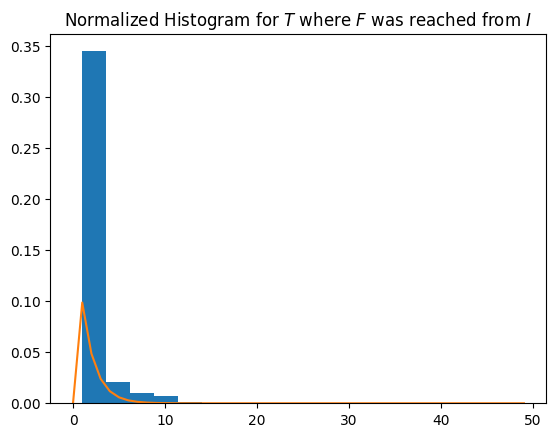

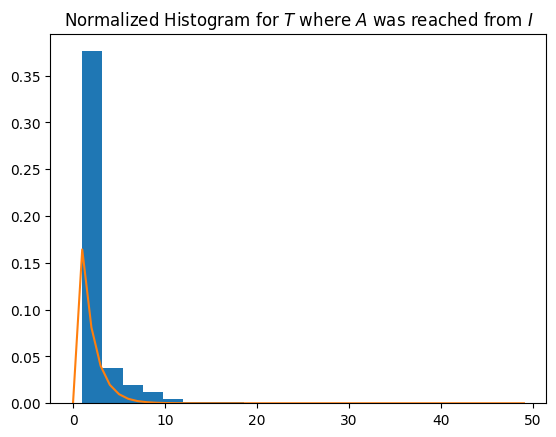

In [110]:
from matplotlib import legend
print(state[1][state[1] == 4])
folded = escTime[1][state[1] == 3]
figF, axF = plt.subplots()
axF.hist(folded, bins=10,  density = True)
axF.set_title("Normalized Histogram for $T$ where $F$ was reached from $I$")
def pmf_F(k):
  return  np.where(k%2 == 0, 0, 1/5*2**(-k))
arr = np.linspace(0,50,50)
axF.plot(pmf_F(arr))
aggregated = escTime[1][state[1] == 4]
figA, axA = plt.subplots()
axA.hist(aggregated, bins = 10, density = True)
axA.set_title("Normalized Histogram for $T$ where $A$ was reached from $I$")
def pmf_A(k):
  return  np.where(k%2 == 0, 0, 1/3*2**(-k))
axA.plot(pmf_A(arr))
